### Importing

In [231]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.datasets import load_iris
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler , label_binarize
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay , classification_report , roc_curve , auc

### Loading Data

In [ ]:
df = pd.read_csv(filepath_or_buffer = "Iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### EDA

In [233]:
df.shape

(150, 5)

In [234]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [235]:
df.duplicated().sum()

np.int64(3)

In [236]:
df = df.drop_duplicates()

In [237]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [238]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 147 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  147 non-null    float64
 1   sepal_width   147 non-null    float64
 2   petal_length  147 non-null    float64
 3   petal_width   147 non-null    float64
 4   species       147 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.9+ KB


In [239]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal_length,147.0,5.856463,0.829100,4.3,5.1,5.8,6.4,7.9
sepal_width,147.0,3.055782,0.437009,2.0,2.8,3.0,3.3,4.4
petal_length,147.0,3.780272,1.759111,1.0,1.6,4.4,5.1,6.9
petal_width,147.0,1.208844,0.757874,0.1,0.3,1.3,1.8,2.5


In [240]:
df["species"].value_counts()

species
versicolor    50
virginica     49
setosa        48
Name: count, dtype: int64

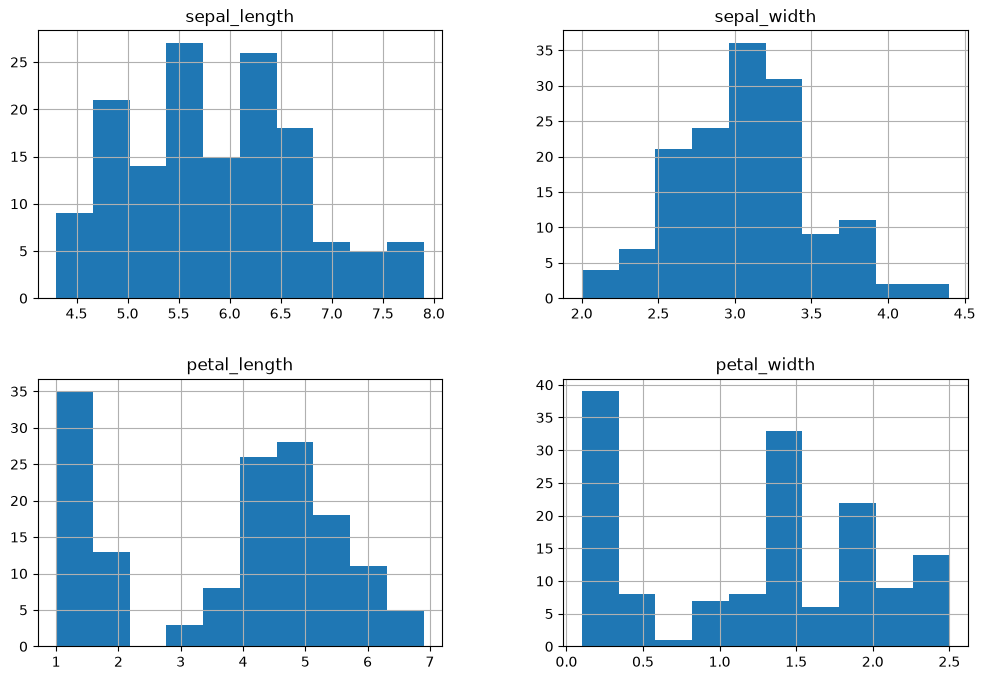

In [241]:
df.hist(figsize = (12 , 8))
plt.show()

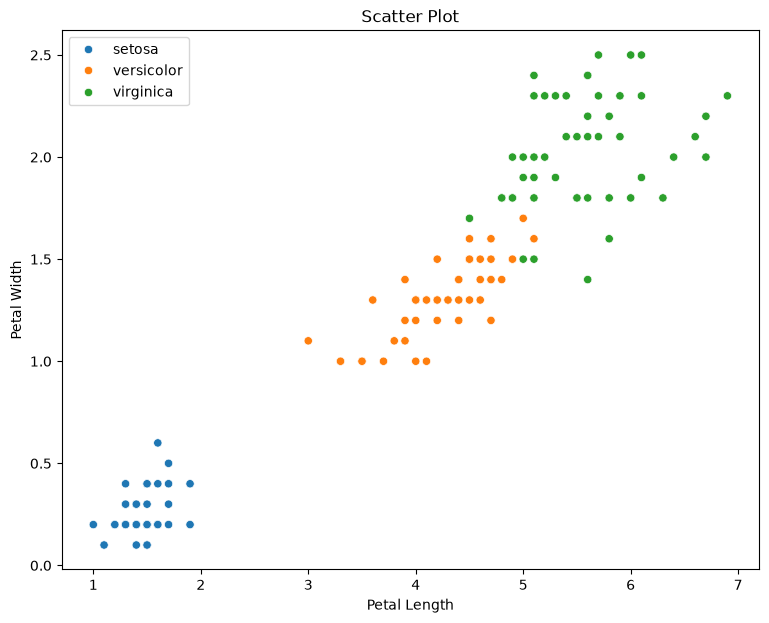

In [242]:
plt.figure(figsize = (9 , 7))
sns.scatterplot(data = df , x = "petal_length" , y = "petal_width" , hue = "species")

plt.title("Scatter Plot")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend()
plt.show()

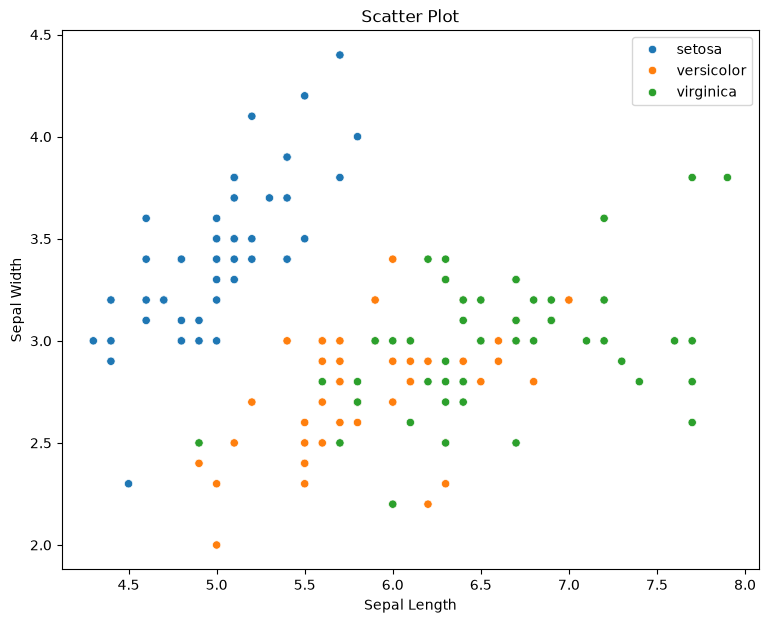

In [243]:
plt.figure(figsize = (9 , 7))
sns.scatterplot(data = df , x = "sepal_length" , y = "sepal_width" , hue = "species")

plt.title("Scatter Plot")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()
plt.show()

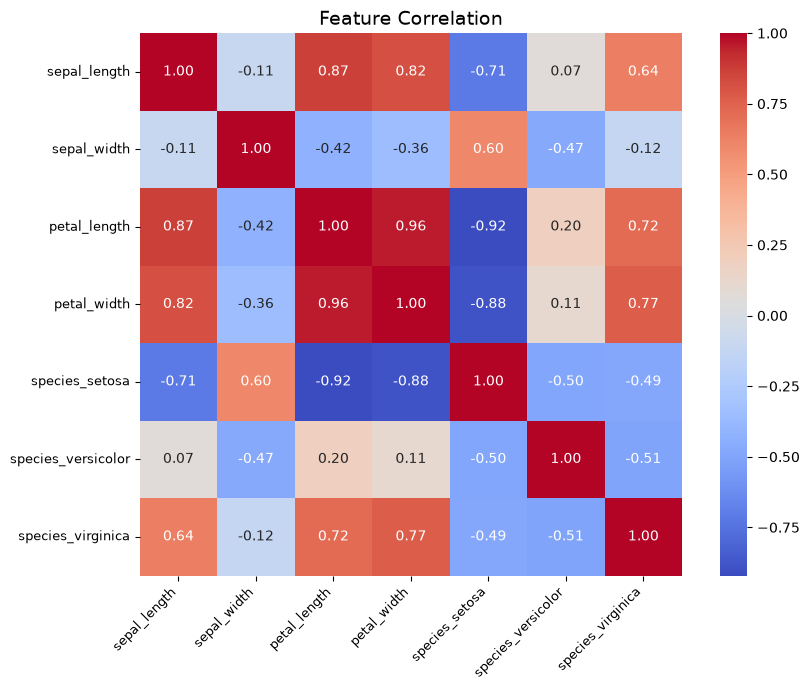

In [244]:
plt.figure(figsize = (9 , 7))
sns.heatmap(pd.get_dummies(df).corr() , annot = True , fmt = ".2f" , square = True , cmap = "coolwarm")

plt.title("Feature Correlation" , fontsize = 14)
plt.xticks(rotation = 45 , ha = "right" , fontsize = 9)
plt.yticks(rotation = 0 , fontsize = 9)
plt.tight_layout()
plt.show()

### Feature & Target Split

In [245]:
X = df.drop(columns = ["species"])
y = df["species"]

### Train & Test Split

In [246]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 101)

### Making Pipeline

In [247]:
scaler = StandardScaler()
model = SVC(probability = True)

In [248]:
pipe = Pipeline([("scaler" , scaler) , ("model" , model)])

### GridSearchCV & Model Training

In [249]:
param_grid = {
    "model__kernel" : ["linear" , "rbf"] , 
    "model__C" : [0.001 , 0.01 , 0.1 , 1.0 , 10.0] ,
    "model__gamma" : ["scale" , "auto"]
}

In [250]:
grid_model = GridSearchCV(estimator = pipe , param_grid = param_grid , cv = 5 , scoring = "accuracy")
grid_model.fit(X_train , y_train)
grid_model.best_params_

{'model__C': 1.0, 'model__gamma': 'scale', 'model__kernel': 'linear'}

### Predication

In [251]:
y_pred = grid_model.predict(X_test)

### Evaluation

In [252]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.92      0.92      0.92        12
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.94        30
weighted avg       0.93      0.93      0.93        30



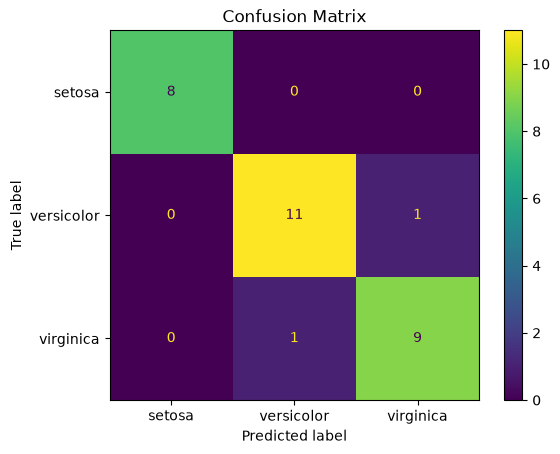

In [253]:
ConfusionMatrixDisplay.from_estimator(estimator = grid_model , X = X_test , y = y_test)
plt.title("Confusion Matrix")
plt.show()

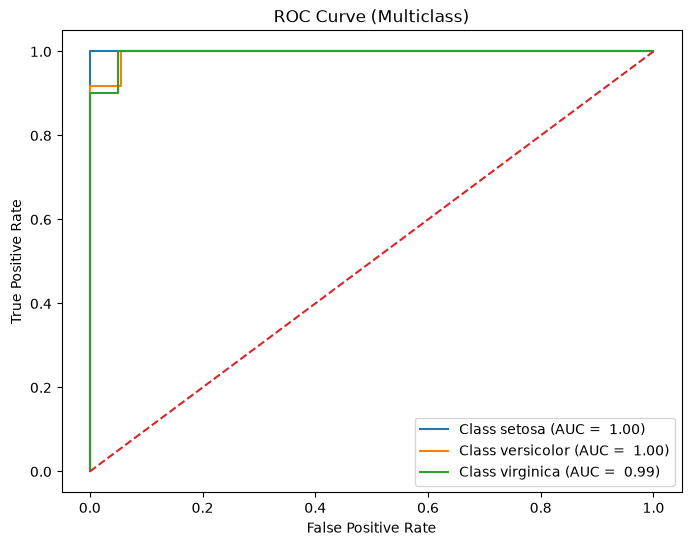

In [254]:
y_score = grid_model.predict_proba(X_test)

classes = grid_model.classes_

y_test_bin = label_binarize(y_test , classes = classes)

plt.figure(figsize = (8 , 6))

for i , cls in enumerate(classes):
    fpr , tpr , _ = roc_curve(y_test_bin[: , i] , y_score[: , i])
    roc_auc = auc(fpr , tpr)
    plt.plot(fpr , tpr , label = f"Class {cls} (AUC = {roc_auc : .2f})")

plt.plot([0 , 1] , [0 , 1] , "--")
plt.title("ROC Curve (Multiclass)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()